<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/AIML_ARIMA_SARIMA_WF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.api as sm


from scipy.stats import zscore
from datetime import datetime, timedelta
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv('/content/GlobalLandTemperaturesByCountry.csv')
df1 = pd.read_csv('/content/GlobalLandTemperaturesByMajorCity.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  object 
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.6+ MB


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239177 entries, 0 to 239176
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             239177 non-null  object 
 1   AverageTemperature             228175 non-null  float64
 2   AverageTemperatureUncertainty  228175 non-null  float64
 3   City                           239177 non-null  object 
 4   Country                        239177 non-null  object 
 5   Latitude                       239177 non-null  object 
 6   Longitude                      239177 non-null  object 
dtypes: float64(2), object(5)
memory usage: 12.8+ MB


In [5]:
df.isnull().sum()

,0
dt,0
AverageTemperature,32651
AverageTemperatureUncertainty,31912
Country,0


In [6]:
df1.isnull().sum()

,0
dt,0
AverageTemperature,11002
AverageTemperatureUncertainty,11002
City,0
Country,0
Latitude,0
Longitude,0


In [7]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [8]:
df1.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


In [9]:
df.shape

(577462, 4)

In [10]:
df1.shape

(239177, 7)

In [11]:
df= df.dropna()

In [12]:
df.isnull().sum()

,0
dt,0
AverageTemperature,0
AverageTemperatureUncertainty,0
Country,0


In [13]:
df.shape

(544811, 4)

In [14]:
df1_filled = df1.dropna()
# Explicitly remove rows where 'AverageTemperature' is infinite
df1_filled = df1_filled[~df1_filled['AverageTemperature'].isin([np.inf, -np.inf])]

In [16]:
df1_filled.shape

(228175, 7)

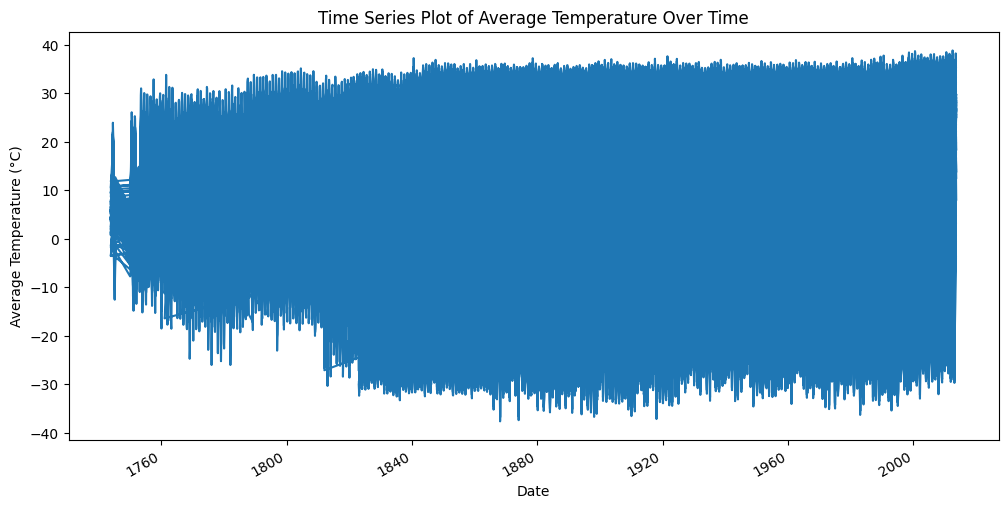

In [17]:
df['dt'] = pd.to_datetime(df['dt'])
df.set_index('dt', inplace=True)

plt.figure(figsize=(12, 6))
df['AverageTemperature'].plot()
plt.title('Time Series Plot of Average Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.show()

In [18]:
df[['AverageTemperature', 'AverageTemperatureUncertainty']].corr()

,AverageTemperature,AverageTemperatureUncertainty
AverageTemperature,1.000000,-0.305041
AverageTemperatureUncertainty,-0.305041,1.000000


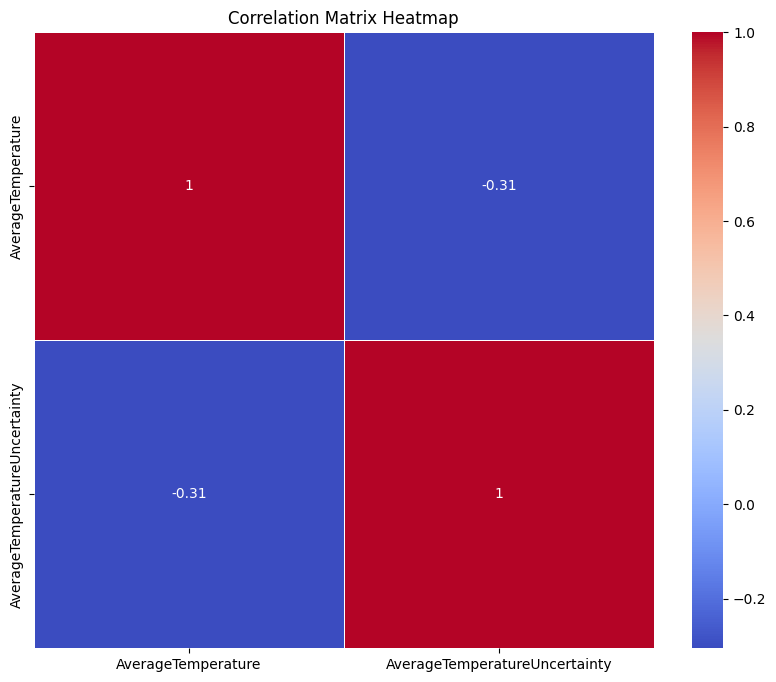

In [19]:
# Heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[['AverageTemperature', 'AverageTemperatureUncertainty']].corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

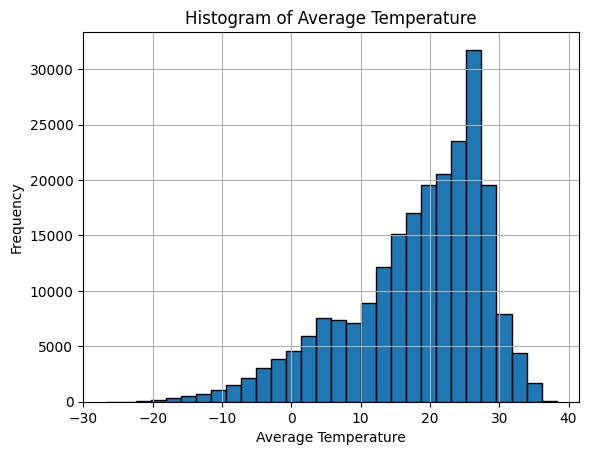

In [20]:
df1_filled['AverageTemperature'].hist(bins=30, edgecolor='black')
plt.title('Histogram of Average Temperature')
plt.xlabel('Average Temperature')
plt.ylabel('Frequency')
plt.show()

In [22]:
z_scores = zscore(df1.interpolate()['AverageTemperature'])
outliers = (z_scores > 3) | (z_scores < -3)

# Display the outliers
print(df1['AverageTemperature'][outliers])

47042    -15.398
47043    -15.507
47054    -13.935
47055    -16.842
47066    -15.663
           ...  
232104   -12.587
232488   -12.886
232501   -11.684
232513   -12.785
232692   -14.051
Name: AverageTemperature, Length: 1719, dtype: float64


/tmp/ipykernel_882/155593956.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  z_scores = zscore(df1.interpolate()['AverageTemperature'])


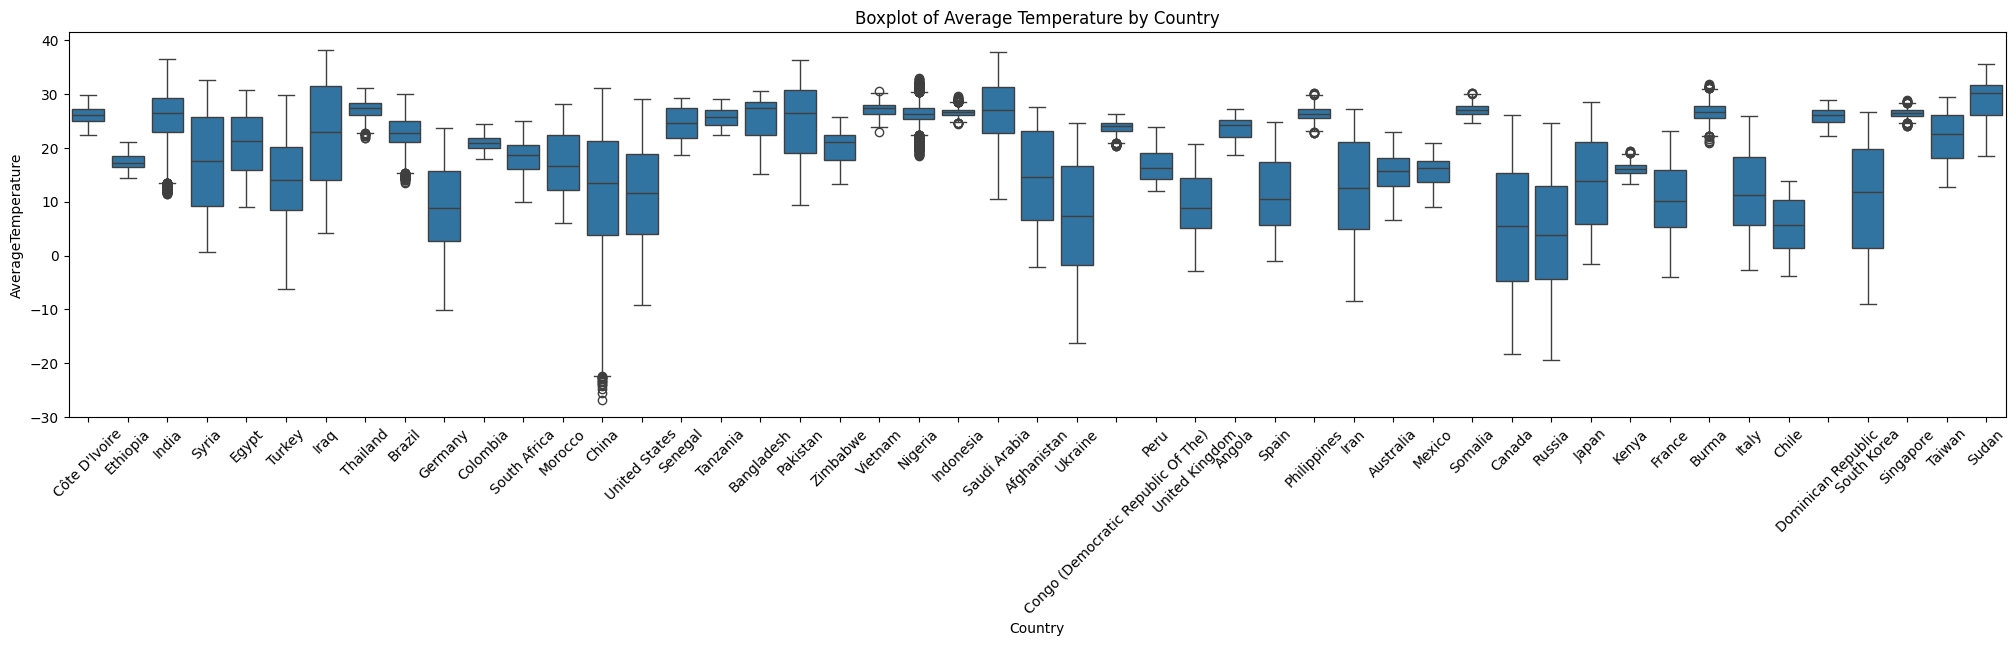

In [23]:
plt.figure(figsize=(25,5))
sns.boxplot(x='Country', y='AverageTemperature', data=df1_filled)
plt.title('Boxplot of Average Temperature by Country')
plt.xticks(rotation=45)
plt.show()

In [24]:
Q1 = df1['AverageTemperature'].quantile(0.25)
Q3 = df1['AverageTemperature'].quantile(0.75)
IQR = Q3 - Q1

outliers = (df1['AverageTemperature'] < (Q1 - 1.5 * IQR)) | (df1['AverageTemperature'] > (Q3 + 1.5 * IQR))

# Display the outliers
print(df1['AverageTemperature'][outliers])

24778     -8.253
24886     -8.336
25041     -7.790
25114     -8.019
25210     -7.389
           ...  
232849    -9.937
232861    -7.318
232872   -10.656
232884    -7.137
232896    -9.348
Name: AverageTemperature, Length: 4395, dtype: float64


In [25]:
print(Q1)
print(Q3)
print(IQR)
print(outliers)

12.71
25.918000000000006
13.208000000000006
0         False
1         False
2         False
3         False
4         False
          ...  
239172    False
239173    False
239174    False
239175    False
239176    False
Name: AverageTemperature, Length: 239177, dtype: bool


In [26]:
df1_filled[['AverageTemperature', 'AverageTemperatureUncertainty']].corr()

,AverageTemperature,AverageTemperatureUncertainty
AverageTemperature,1.00000,-0.19938
AverageTemperatureUncertainty,-0.19938,1.00000


In [28]:
df1_filled

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W
...,...,...,...,...,...,...,...
239171,2013-04-01,12.563,1.823,Xian,China,34.56N,108.97E
239172,2013-05-01,18.979,0.807,Xian,China,34.56N,108.97E
239173,2013-06-01,23.522,0.647,Xian,China,34.56N,108.97E
239174,2013-07-01,25.251,1.042,Xian,China,34.56N,108.97E


In [29]:
df1_filled.rename(columns={'dt':'Date', 'AverageTemperature':'Avg_temp', 'confidence_interval_temp':'Avg_Temp_Un'}, inplace=True)
df1_filled.head()

,Date,Avg_temp,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


In [30]:
# Convert 'Date' to datetime and filter for years 1980-2013
df1_temp = df1_filled.copy()
df1_temp['Date'] = pd.to_datetime(df1_temp['Date'])
latest_df = df1_temp[(df1_temp['Date'].dt.year >= 1980) & (df1_temp['Date'].dt.year <= 2013)].copy()
# Set 'Date' column as the index for proper time series operations
latest_df = latest_df.set_index('Date')
latest_df.head()

,Avg_temp,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
Date,,,,,,
1980-01-01,27.409,0.497,Abidjan,Côte D'Ivoire,5.63N,3.23W
1980-02-01,28.192,0.358,Abidjan,Côte D'Ivoire,5.63N,3.23W
1980-03-01,28.303,0.430,Abidjan,Côte D'Ivoire,5.63N,3.23W
1980-04-01,28.284,0.223,Abidjan,Côte D'Ivoire,5.63N,3.23W
1980-05-01,26.709,0.383,Abidjan,Côte D'Ivoire,5.63N,3.23W


In [31]:
# Resample to yearly mean and drop any resulting NaN values
resample_df = latest_df[['Avg_temp']].resample('YE').mean()
resample_df = resample_df.dropna() # Drop years with no data after resampling
resample_df.head()

,Avg_temp
Date,
1980-12-31,19.068541
1981-12-31,19.115568
1982-12-31,19.068149
1983-12-31,19.197572
1984-12-31,18.960732


In [32]:
print('Dickey Fuller Test Results:')
test_df= adfuller(resample_df.iloc[:,0].values, autolag='AIC')
df_output = pd.Series(test_df[0:4], index=['Text Statistic', 'p-value', 'Lags Used', 'Number of observations'])
for key, value in test_df[4].items():
    df_output['Critical Value (%s)'%key] = value
print(df_output)

Dickey Fuller Test Results:
Text Statistic            -0.681770
p-value                    0.851415
Lags Used                  2.000000
Number of observations    31.000000
Critical Value (1%)       -3.661429
Critical Value (5%)       -2.960525
Critical Value (10%)      -2.619319
dtype: float64


In [33]:
#Decomposing the time series into trend, seasonal, and residual components
decomp = seasonal_decompose(resample_df, period=3)

trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid

In [34]:
#Creating subplots to visualize decomposition
fig = make_subplots(rows=4, cols=1, subplot_titles=('Original', 'Trend', 'Seasonal', 'Residual'))

#Plotting the original time series
fig.add_trace(go.Scatter(x=resample_df.index, y=resample_df['Avg_temp'], mode='lines', name='Original'), row=1, col=1)

#Plotting the trend component
fig.add_trace(go.Scatter(x=trend.index, y=trend, mode='lines', name='Trend'), row=2, col=1)

#Plotting the seasonal component
fig.add_trace(go.Scatter(x=seasonal.index, y=seasonal, mode='lines', name='Seasonal'), row=3, col=1)

#Plotting the residual component
fig.add_trace(go.Scatter(x=residual.index, y=residual, mode='lines', name='Residual'), row=4, col=1)

#Updating layout
fig.update_layout(title='Temperature Decomposition',
                  xaxis_title='Year',
                  yaxis_title='Temperature')
fig.show()

In [35]:
# Calculate rolling mean, exponentially weighted mean, and rolling standard deviation
rol_mean = resample_df.rolling(window=3, center=True).mean()
ewm = resample_df.ewm(span=3).mean()
rol_std = resample_df.rolling(window=3, center=True).std()

print('Rolling mean', rol_mean.head())
print('Exponentially weighted mean', ewm.head())
print('Rolling standard deviation', rol_std.head())

Rolling mean              Avg_temp
Date                 
1980-12-31        NaN
1981-12-31  19.084086
1982-12-31  19.127097
1983-12-31  19.075484
1984-12-31  19.051813
Exponentially weighted mean              Avg_temp
Date                 
1980-12-31  19.068541
1981-12-31  19.099892
1982-12-31  19.081753
1983-12-31  19.143524
1984-12-31  19.049179
Rolling standard deviation             Avg_temp
Date                
1980-12-31       NaN
1981-12-31  0.027265
1982-12-31  0.065477
1983-12-31  0.118591
1984-12-31  0.127537


In [36]:
rol_mean.dropna(inplace=True)
ewm.dropna(inplace=True)

# Printing results of the Dickey-Fuller Test for Rolling Mean
print('Dickey-Fuller Test for the Rolling Mean:')
df_test = adfuller(rol_mean.iloc[:, 0].values, autolag='AIC')
df_output = pd.Series(df_test[0:4], index=['Test Statistic', 'p-value', 'Lags Used', 'Number of Observations Used'])
for key, value in df_test[4].items():
    df_output['Critical Value (%s)' % key] = value
print(df_output)
print('')

# Printing results of the Dickey-Fuller Test for Exponentially Weighted Mean
print('Dickey-Fuller Test for the Exponentially Weighted Mean:')
df_test = adfuller(ewm.iloc[:, 0].values, autolag='AIC')
df_output = pd.Series(df_test[0:4], index=['Test Statistic', 'p-value', 'Lags Used', 'Number of Observations Used'])
for key, value in df_test[4].items():
    df_output['Critical Value (%s)' % key] = value
print(df_output)

Dickey-Fuller Test for the Rolling Mean:
Test Statistic                 -0.656891
p-value                         0.857602
Lags Used                       5.000000
Number of Observations Used    26.000000
Critical Value (1%)            -3.711212
Critical Value (5%)            -2.981247
Critical Value (10%)           -2.630095
dtype: float64

Dickey-Fuller Test for the Exponentially Weighted Mean:
Test Statistic                 -0.321583
p-value                         0.922391
Lags Used                       2.000000
Number of Observations Used    31.000000
Critical Value (1%)            -3.661429
Critical Value (5%)            -2.960525
Critical Value (10%)           -2.619319
dtype: float64


In [37]:
# Calculating differences between the Original and Rolling Mean
diff_rol_mean = resample_df - rol_mean
diff_rol_mean.dropna(inplace=True)
diff_rol_mean.head()

,Avg_temp
Date,
1981-12-31,0.031482
1982-12-31,-0.058948
1983-12-31,0.122088
1984-12-31,-0.091082
1985-12-31,-0.003739


In [38]:
# Calculating differences between the Original and Exponentially Weighted Mean
diff_ewm = resample_df - ewm
diff_ewm.dropna(inplace=True)
diff_ewm.head()

,Avg_temp
Date,
1980-12-31,0.000000
1981-12-31,0.015676
1982-12-31,-0.013604
1983-12-31,0.054049
1984-12-31,-0.088448


In [39]:
# Calculating rolling mean and exponentially weighted mean for differences
df_rol_mean_diff = diff_rol_mean.rolling(window=3, center=True).mean()
df_ewm_diff = diff_ewm.ewm(span=3).mean()
df_rol_mean_diff.head()

,Avg_temp
Date,
1981-12-31,NaN
1982-12-31,0.031541
1983-12-31,-0.009314
1984-12-31,0.009089
1985-12-31,-0.066738


In [40]:
# Printing results of the Dickey-Fuller Test for the Difference between the Original and Rolling Mean
print('Dickey-Fuller Test for the Difference between the Original and Rolling Mean:')
dftest = adfuller(diff_rol_mean.iloc[:, 0].values, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)' % key] = value
print(dfoutput)
print('')

Dickey-Fuller Test for the Difference between the Original and Rolling Mean:
Test Statistic                 -5.127399
p-value                         0.000012
# Lags Used                     3.000000
Number of Observations Used    28.000000
Critical Value (1%)            -3.688926
Critical Value (5%)            -2.971989
Critical Value (10%)           -2.625296
dtype: float64



In [41]:
#Applying ARIMA model
train_size = int(len(resample_df) * 0.8)
train, test = resample_df.iloc[:train_size], resample_df.iloc[train_size:]

In [42]:
#Fitting the ARIMA model
model = ARIMA(train, order=(5, 1, 0))
fit_model = model.fit()

In [43]:
#Forecasting
predictions = fit_model.forecast(steps=len(test))
predictions

,predicted_mean
2007-12-31,19.692215
2008-12-31,19.670660
2009-12-31,19.677779
2010-12-31,19.747024
2011-12-31,19.694824
2012-12-31,19.678308
2013-12-31,19.698481


In [44]:
#Evaluating the model
rmse = sqrt(mean_squared_error(test, predictions))
print(f'Root Mean Squared Error (RMSE): {rmse}')

Root Mean Squared Error (RMSE): 0.24539929849869824


In [45]:
#Creating a figure
fig = go.Figure()

#Plotting the train data
fig.add_trace(go.Scatter(x=train.index, y=train['Avg_temp'], mode='markers,lines', name='Train'))

#Plotting the test data
fig.add_trace(go.Scatter(x=test.index, y=test['Avg_temp'], mode='markers,lines', name='Test'))

#Plotting the predictions data
fig.add_trace(go.Scatter(x=test.index, y=predictions, mode='markers,lines', name='Predictions'))

#Adding layout information
fig.update_layout(title='ARIMA Model Forecast',
                  xaxis_title='Date',
                  yaxis_title='Temperature',
                  legend=dict(x=0, y=1, traceorder='normal'))

In [46]:
#Hyperparameter Tuning
best_rmse = float('inf')
best_order = None

for p in range(1, 5):
    for d in range(1, 3):
        for q in range(1, 5):
            order = (p, d, q)
            model = ARIMA(train, order=order)
            fit_model = model.fit()
            predictions = fit_model.forecast(steps=len(test))
            rmse = sqrt(mean_squared_error(test, predictions))

            if rmse < best_rmse:
                best_rmse = rmse
                best_order = order

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros

In [47]:
final_model = ARIMA(resample_df, order=best_order)
fit_model = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [48]:
predictions = fit_model.forecast(steps=len(test))


In [49]:
rmse = sqrt(mean_squared_error(test, predictions))
print(f'Root Mean Squared Error (RMSE): {rmse}')

Root Mean Squared Error (RMSE): 0.2645429035251388


In [50]:
#Creating a figure
fig = go.Figure()

#Plotting the train data
fig.add_trace(go.Scatter(x=train.index, y=train['Avg_temp'], mode='markers,lines', name='Train'))

#Plotting the test data
fig.add_trace(go.Scatter(x=test.index, y=test['Avg_temp'], mode='markers,lines', name='Test'))

#Plotting the predictions data
fig.add_trace(go.Scatter(x=test.index, y=predictions, mode='markers,lines', name='Predictions'))

#Adding layout information
fig.update_layout(title='ARIMA Model Forecast',
                  xaxis_title='Date',
                  yaxis_title='Temperature',
                  legend=dict(x=0, y=1, traceorder='normal'))

#Showing the figure
fig.show()


In [51]:
df1_filled={'AverageTemperature': np.random.rand(100) * 10 + 20}

In [52]:
df1_filled = pd.DataFrame(df1_filled, index=pd.date_range(start='2022-01-01', periods=100, freq='ME'))

In [53]:
result = adfuller(df1_filled['AverageTemperature'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])


ADF Statistic: -9.126232061241222
p-value: 3.1083143250387617e-15
Critical Values: {'1%': np.float64(-3.498198082189098), '5%': np.float64(-2.891208211860468), '10%': np.float64(-2.5825959973472097)}


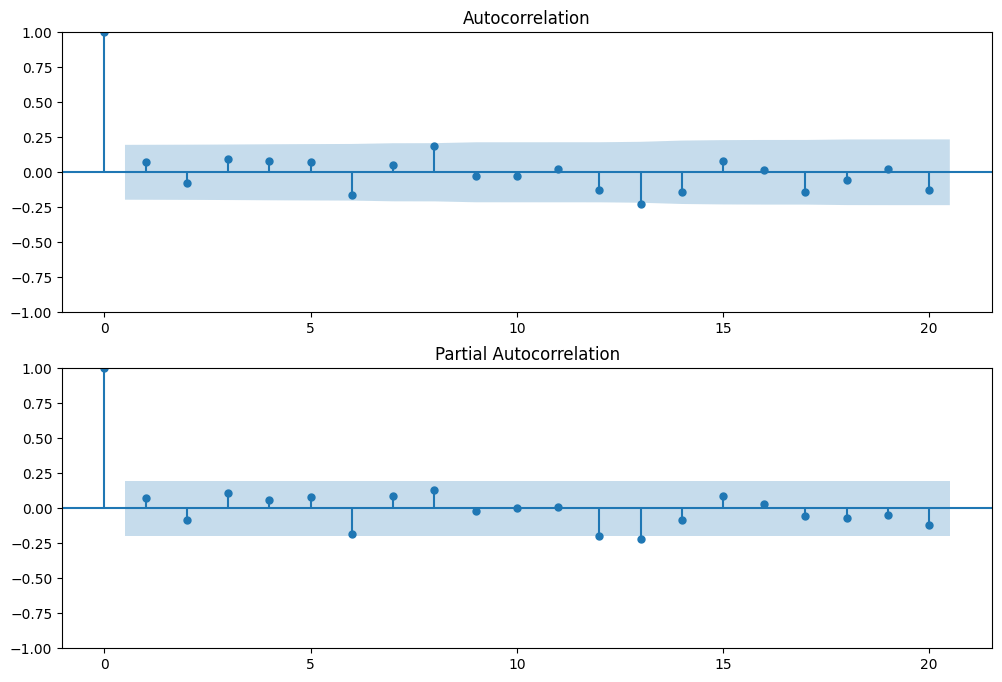

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df1_filled['AverageTemperature'], lags=20, ax=ax1)
plot_pacf(df1_filled['AverageTemperature'], lags=20, ax=ax2)
plt.show()

In [55]:
order = (1, 1, 1)  # Non-seasonal order
seasonal_order = (1, 1, 1, 12)  # Seasonal order

model = SARIMAX(df1_filled['AverageTemperature'], order=order, seasonal_order=seasonal_order)
results = model.fit()

# Step 4: Validate and Evaluate
# Example: Forecasting the next 12 months
forecast_steps = 100
forecast = results.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df1_filled.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='ME')

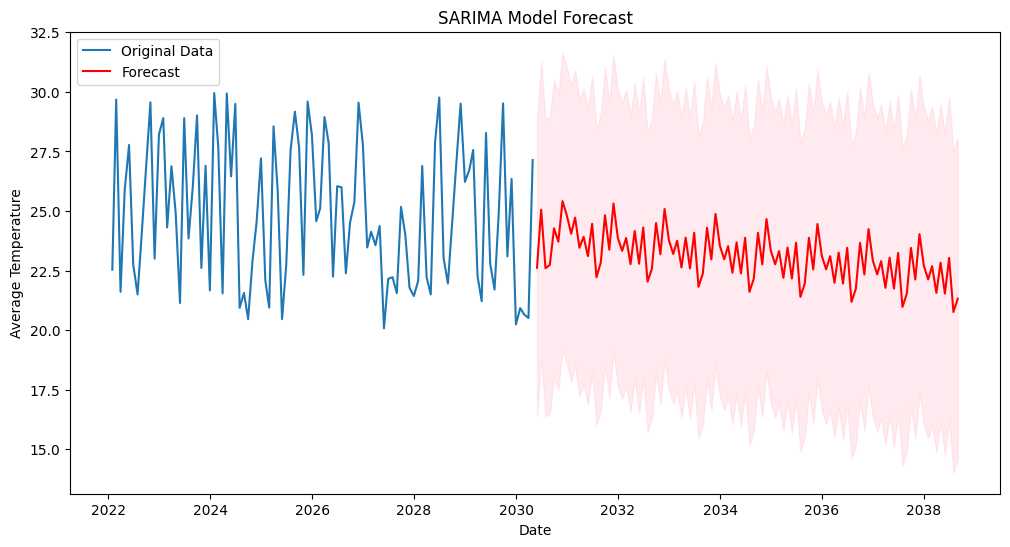

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(df1_filled['AverageTemperature'], label='Original Data')
plt.plot(forecast_index, forecast.predicted_mean, color='red', label='Forecast')
plt.fill_between(forecast_index,
                 forecast.conf_int()['lower AverageTemperature'],
                 forecast.conf_int()['upper AverageTemperature'],
                 color='pink', alpha=0.3)
plt.title('SARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()


In [57]:
forecast.predicted_mean.count()

np.int64(100)

In [58]:
df1_filled['AverageTemperature'].shape[0]

100

In [59]:
# Evaluate the model
mse = mean_squared_error(df1_filled['AverageTemperature'], forecast.predicted_mean)
print("Mean Squared Error:", mse)

Mean Squared Error: 13.197771034017997
